In [1]:
import numpy as np
import pandas as pd

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, fcluster

import matplotlib.pyplot as plt

In [2]:
formations = pd.read_csv("top500_data/top500_formations.csv")
history = pd.read_csv("top500_data/selected_stock_monthly_history.csv")

print(formations.shape)
print(history.shape)

display(formations.head())
display(history.head())

(186000, 9)
(392863, 4)


,month,permno,mthcap,mthprc,weight,n_price_months,n_return_months,has_60_prices,has_60_returns
0,1995-01,12060,88047490.00,51.500,0.024625,1.0,1.0,False,False
1,1995-01,10401,77956919.25,49.875,0.021803,1.0,1.0,False,False
2,1995-01,11850,77591000.00,62.500,0.021701,1.0,1.0,False,False
3,1995-01,11308,67501350.00,52.500,0.018879,1.0,1.0,False,False
4,1995-01,55976,52571874.00,22.875,0.014704,1.0,1.0,False,False


,month,permno,mthprc,mthret
0,1995-01,10078,32.750,-0.077465
1,1995-01,10104,42.625,-0.033994
2,1995-01,10107,59.375,-0.028630
3,1995-01,10108,35.750,-0.071429
4,1995-01,10137,24.000,0.103448


In [3]:
formations["month"] = pd.PeriodIndex(formations["month"], freq="M")
history["month"] = pd.PeriodIndex(history["month"], freq="M")

print(formations["month"].min(), formations["month"].max())
print(history["month"].min(), history["month"].max())

1995-01 2025-12
1995-01 2025-12


In [4]:
formation_month = pd.Period("1999-12", freq="M")

current_universe = formations[
    formations["month"] == formation_month
].copy()

print("Stocks in benchmark universe:", len(current_universe))

display(current_universe.head())

Stocks in benchmark universe: 500


,month,permno,mthcap,mthprc,weight,n_price_months,n_return_months,has_60_prices,has_60_returns
29500,1999-12,10107,6.024329e+08,116.7500,0.045987,60.0,60.0,True,True
29501,1999-12,12060,5.072166e+08,154.7500,0.038718,60.0,60.0,True,True
29502,1999-12,76076,3.504242e+08,107.1250,0.026750,60.0,60.0,True,True
29503,1999-12,55976,3.078648e+08,69.1250,0.023501,60.0,60.0,True,True
29504,1999-12,11850,2.788731e+08,80.5625,0.021288,60.0,60.0,True,True


In [5]:
eligible = current_universe[
    current_universe["has_60_returns"]
].copy()

print("Top-500 stocks:", len(current_universe))
print("Stocks eligible for clustering:", len(eligible))
print("Stocks excluded due to insufficient history:",
      len(current_universe) - len(eligible))

Top-500 stocks: 500
Stocks eligible for clustering: 382
Stocks excluded due to insufficient history: 118


In [6]:
start_month = formation_month - 59

print("Start:", start_month)
print("End:", formation_month)

Start: 1995-01
End: 1999-12


In [7]:
eligible_permnos = eligible["permno"].tolist()

window = history[
    (history["month"] >= start_month) &
    (history["month"] <= formation_month) &
    (history["permno"].isin(eligible_permnos))
].copy()

display(window.head())

print("Rows:", len(window))

,month,permno,mthprc,mthret
0,1995-01,10078,32.750,-0.077465
1,1995-01,10104,42.625,-0.033994
2,1995-01,10107,59.375,-0.028630
5,1995-01,10138,27.500,-0.083333
6,1995-01,10145,35.750,0.051471


Rows: 22920


In [8]:
return_matrix = window.pivot(
    index="month",
    columns="permno",
    values="mthret"
)

return_matrix = return_matrix.sort_index()

print(return_matrix.shape)
display(return_matrix.head())

(60, 382)


permno,10078,10104,10107,10138,10145,10147,10225,10299,10353,10401,...,81126,81593,82959,84129,85914,86976,87055,90537,90609,92655
month,,,,,,,,,,,,,,,,,,,,,
1995-01,-0.077465,-0.033994,-0.028630,-0.083333,0.051471,-0.153409,0.013333,0.001407,0.158730,-0.007463,...,0.117188,0.055624,0.031579,0.052265,-0.008000,0.069364,0.067961,-0.148936,0.036496,0.074792
1995-02,-0.022901,0.104106,0.061053,0.163636,0.064859,-0.080537,-0.006796,0.101010,0.205479,0.035088,...,0.013986,0.141844,0.102475,0.059603,-0.298387,-0.229730,-0.009091,0.100000,0.145246,-0.113402
1995-03,0.085938,-0.003984,0.128968,0.142539,0.036304,-0.021898,0.053691,0.027523,0.000000,0.008737,...,0.027586,-0.003106,0.013954,-0.048872,-0.005747,0.123080,0.082569,0.113636,-0.065334,0.087880
1995-04,0.147482,-0.024000,0.149385,0.010309,0.009554,0.156716,0.031847,0.068236,-0.030303,-0.019324,...,0.067114,0.031052,-0.059633,0.129139,0.265896,0.084640,-0.008475,0.081633,0.144737,-0.224599
1995-05,0.128527,0.139344,0.035933,-0.006803,0.023701,0.187097,0.009453,0.025105,-0.058594,0.000000,...,0.188679,0.097561,-0.014296,0.061584,-0.109589,-0.017341,-0.034188,0.113208,-0.109195,0.027586


In [9]:
print("Number of months:", return_matrix.shape[0])
print("Number of stocks:", return_matrix.shape[1])
print("Missing returns:", return_matrix.isna().sum().sum())

Number of months: 60
Number of stocks: 382
Missing returns: 0


In [10]:
assert return_matrix.shape[0] == 60
assert return_matrix.isna().sum().sum() == 0

print("60-month return matrix looks good.")

60-month return matrix looks good.


In [11]:
corr_matrix = return_matrix.corr()

print(corr_matrix.shape)
display(corr_matrix.iloc[:5, :5])

(382, 382)


permno,10078,10104,10107,10138,10145
permno,,,,,
10078,1.000000,0.337922,0.469470,0.066419,0.179812
10104,0.337922,1.000000,0.345831,0.016309,0.056241
10107,0.469470,0.345831,1.000000,0.258933,0.074131
10138,0.066419,0.016309,0.258933,1.000000,0.196540
10145,0.179812,0.056241,0.074131,0.196540,1.000000


In [12]:
distance_array = np.array(1 - corr_matrix, dtype=float, copy=True)

# Numerical cleanup
distance_array = np.clip(distance_array, 0, None)

# Set diagonal to exactly zero
np.fill_diagonal(distance_array, 0.0)

# Convert back to DataFrame so we keep the PERMNO labels
distance_matrix = pd.DataFrame(
    distance_array,
    index=corr_matrix.index,
    columns=corr_matrix.columns
)

display(distance_matrix.iloc[:5, :5])

permno,10078,10104,10107,10138,10145
permno,,,,,
10078,0.000000,0.662078,0.530530,0.933581,0.820188
10104,0.662078,0.000000,0.654169,0.983691,0.943759
10107,0.530530,0.654169,0.000000,0.741067,0.925869
10138,0.933581,0.983691,0.741067,0.000000,0.803460
10145,0.820188,0.943759,0.925869,0.803460,0.000000


In [13]:
print(distance_array.flags.writeable)
print(np.diag(distance_matrix).max())

True
0.0


In [14]:
condensed_distance = squareform(
    distance_matrix.to_numpy(),
    checks=False
)

print(condensed_distance.shape)

(72771,)


In [15]:
Z = linkage(
    condensed_distance,
    method="average"
)

print(Z.shape)

(381, 4)


In [16]:
k = 25

cluster_labels = fcluster(
    Z,
    t=k,
    criterion="maxclust"
)

clusters = pd.DataFrame({
    "permno": corr_matrix.columns,
    "cluster": cluster_labels
})

print("Number of clusters:", clusters["cluster"].nunique())

display(clusters.head(10))

Number of clusters: 25


,permno,cluster
0,10078,17
1,10104,14
2,10107,17
3,10138,7
4,10145,8
5,10147,17
6,10225,7
7,10299,17
8,10353,17
9,10401,7


In [17]:
cluster_sizes = (
    clusters.groupby("cluster")
    .size()
    .sort_values(ascending=False)
)

display(cluster_sizes)

cluster
7     113
8      70
17     36
14     34
9      26
24     20
13     15
4       9
20      9
1       6
10      6
11      6
5       6
16      4
12      4
23      3
15      3
18      3
19      2
2       2
3       1
6       1
21      1
22      1
25      1
dtype: int64

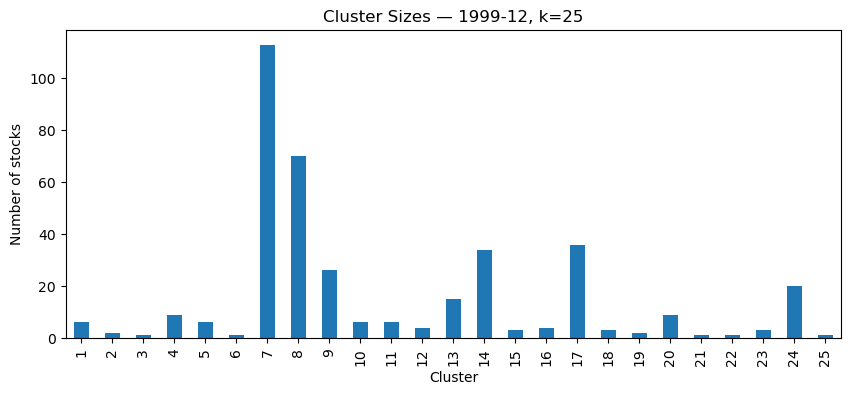

In [18]:
cluster_sizes.sort_index().plot(
    kind="bar",
    figsize=(10, 4)
)

plt.xlabel("Cluster")
plt.ylabel("Number of stocks")
plt.title(f"Cluster Sizes — {formation_month}, k={k}")
plt.show()

In [19]:
def choose_cluster_representatives(clusters, distance_matrix):
    
    representatives = []

    for cluster_id, group in clusters.groupby("cluster"):
        
        members = group["permno"].tolist()

        # If the cluster only contains one stock,
        # that stock is automatically the representative
        if len(members) == 1:
            representative = members[0]

        else:
            cluster_distances = distance_matrix.loc[
                members, members
            ]

            average_distance = cluster_distances.mean(axis=1)

            representative = average_distance.idxmin()

        representatives.append({
            "cluster": cluster_id,
            "representative_permno": representative,
            "cluster_size": len(members)
        })

    return pd.DataFrame(representatives)

In [20]:
representatives_25 = choose_cluster_representatives(
    clusters,
    distance_matrix
)

print("Number selected:", len(representatives_25))

display(representatives_25.head(10))

Number selected: 25


,cluster,representative_permno,cluster_size
0,1,63773,6
1,2,43610,2
2,3,58990,1
3,4,66093,9
4,5,49680,6
5,6,77605,1
6,7,25081,113
7,8,22509,70
8,9,10604,26
9,10,14008,6


In [21]:
representatives_25 = representatives_25.merge(
    current_universe[
        ["permno", "mthcap", "weight"]
    ],
    left_on="representative_permno",
    right_on="permno",
    how="left"
)

representatives_25 = representatives_25.drop(
    columns="permno"
)

display(representatives_25.head())

,cluster,representative_permno,cluster_size,mthcap,weight
0,1,63773,6,6.904800e+06,0.000527
1,2,43610,2,1.798702e+07,0.001373
2,3,58990,1,4.640320e+06,0.000354
3,4,66093,9,1.663047e+08,0.012695
4,5,49680,6,6.868194e+06,0.000524


In [22]:
def select_representatives_for_k(
    Z,
    corr_matrix,
    distance_matrix,
    k
):
    
    labels = fcluster(
        Z,
        t=k,
        criterion="maxclust"
    )

    clusters = pd.DataFrame({
        "permno": corr_matrix.columns,
        "cluster": labels
    })

    representatives = choose_cluster_representatives(
        clusters,
        distance_matrix
    )

    representatives["k"] = k

    return clusters, representatives

In [23]:
results = {}

for k in [25, 50, 100]:
    
    clusters_k, representatives_k = (
        select_representatives_for_k(
            Z,
            corr_matrix,
            distance_matrix,
            k
        )
    )

    results[k] = {
        "clusters": clusters_k,
        "representatives": representatives_k
    }

    print(
        f"k={k}: "
        f"{len(representatives_k)} representatives selected"
    )

k=25: 25 representatives selected
k=50: 50 representatives selected
k=100: 100 representatives selected


In [26]:
def cluster_one_month(
    formation_month,
    formations,
    history,
    k_values=(25, 50, 100),
    lookback=60
):
    
    # --------------------------------------------------
    # 1. Current top-500 universe
    # --------------------------------------------------
    
    current_universe = formations[
        formations["month"] == formation_month
    ].copy()

    if len(current_universe) != 500:
        raise ValueError(
            f"{formation_month}: expected 500 stocks, "
            f"found {len(current_universe)}"
        )

    
    # --------------------------------------------------
    # 2. Stocks with full 60-month return history
    # --------------------------------------------------
    
    eligible = current_universe[
        current_universe["has_60_returns"]
    ].copy()

    eligible_permnos = eligible["permno"].tolist()

    
    # --------------------------------------------------
    # 3. Previous 60 months of returns
    # --------------------------------------------------
    
    start_month = formation_month - (lookback - 1)

    window = history[
        (history["month"] >= start_month) &
        (history["month"] <= formation_month) &
        (history["permno"].isin(eligible_permnos))
    ].copy()

    return_matrix = window.pivot(
        index="month",
        columns="permno",
        values="mthret"
    ).sort_index()

    
    # --------------------------------------------------
    # 4. Sanity checks
    # --------------------------------------------------
    
    if return_matrix.shape[0] != lookback:
        raise ValueError(
            f"{formation_month}: expected {lookback} months, "
            f"found {return_matrix.shape[0]}"
        )

    if return_matrix.isna().any().any():
        raise ValueError(
            f"{formation_month}: missing returns remain"
        )

    
    # --------------------------------------------------
    # 5. Correlations
    # --------------------------------------------------
    
    corr_matrix = return_matrix.corr()

    
    # --------------------------------------------------
    # 6. Convert correlation into distance
    # --------------------------------------------------
    
    distance_array = np.array(
    1 - corr_matrix,
    dtype=float,
    copy=True
    )
    
    distance_array = np.clip(
        distance_array,
        0,
        None
    )
    
    np.fill_diagonal(
        distance_array,
        0.0
    )
    
    distance_matrix = pd.DataFrame(
        distance_array,
        index=corr_matrix.index,
        columns=corr_matrix.columns
    )

    
    # --------------------------------------------------
    # 7. Hierarchical clustering
    # --------------------------------------------------
    
    condensed_distance = squareform(
        distance_array,
        checks=False
    )

    Z = linkage(
        condensed_distance,
        method="average"
    )

    
    # --------------------------------------------------
    # 8. Select representatives for each k
    # --------------------------------------------------
    
    outputs = []

    for k in k_values:

        labels = fcluster(
            Z,
            t=k,
            criterion="maxclust"
        )

        clusters = pd.DataFrame({
            "permno": corr_matrix.columns,
            "cluster": labels
        })

        representatives = choose_cluster_representatives(
            clusters,
            distance_matrix
        )

        representatives["month"] = formation_month
        representatives["k"] = k

        outputs.append(representatives)

    
    representatives_all = pd.concat(
        outputs,
        ignore_index=True
    )

    return representatives_all

In [27]:
test_results = cluster_one_month(
    pd.Period("1999-12", freq="M"),
    formations,
    history
)

display(test_results)

print(
    test_results.groupby("k")
    ["representative_permno"]
    .nunique()
)

,cluster,representative_permno,cluster_size,month,k
0,1,63773,6,1999-12,25
1,2,43610,2,1999-12,25
2,3,58990,1,1999-12,25
3,4,66093,9,1999-12,25
4,5,49680,6,1999-12,25
...,...,...,...,...,...
170,96,13901,2,1999-12,100
171,97,23473,1,1999-12,100
172,98,24985,19,1999-12,100
173,99,50032,1,1999-12,100


k
25      25
50      50
100    100
Name: representative_permno, dtype: int64


In [28]:
formation_months = sorted(
    formations.loc[
        formations["month"] >= pd.Period("1999-12", freq="M"),
        "month"
    ].unique()
)

print("Number of formation months:", len(formation_months))
print("First:", formation_months[0])
print("Last:", formation_months[-1])

Number of formation months: 313
First: 1999-12
Last: 2025-12


In [29]:
all_results = []

for i, month in enumerate(formation_months):

    monthly_results = cluster_one_month(
        month,
        formations,
        history,
        k_values=(25, 50, 100)
    )

    all_results.append(monthly_results)

    if (i + 1) % 25 == 0:
        print(
            f"Completed {i + 1} / "
            f"{len(formation_months)} months"
        )

selection_results = pd.concat(
    all_results,
    ignore_index=True
)

Completed 25 / 313 months
Completed 50 / 313 months
Completed 75 / 313 months
Completed 100 / 313 months
Completed 125 / 313 months
Completed 175 / 313 months
Completed 200 / 313 months
Completed 225 / 313 months
Completed 250 / 313 months
Completed 275 / 313 months
Completed 300 / 313 months


In [31]:
print(selection_results.shape)

display(selection_results.head(20))

(54775, 5)


,cluster,representative_permno,cluster_size,month,k
0,1,63773,6,1999-12,25
1,2,43610,2,1999-12,25
2,3,58990,1,1999-12,25
3,4,66093,9,1999-12,25
4,5,49680,6,1999-12,25
5,6,77605,1,1999-12,25
6,7,25081,113,1999-12,25
7,8,22509,70,1999-12,25
8,9,10604,26,1999-12,25
9,10,14008,6,1999-12,25


In [32]:
selection_check = (
    selection_results
    .groupby(["month", "k"])
    ["representative_permno"]
    .nunique()
    .unstack()
)

display(selection_check.head())

print(selection_check.describe())

k,25,50,100
month,,,
1999-12,25,50,100
2000-01,25,50,100
2000-02,25,50,100
2000-03,25,50,100
2000-04,25,50,100


k        25     50     100
count  313.0  313.0  313.0
mean    25.0   50.0  100.0
std      0.0    0.0    0.0
min     25.0   50.0  100.0
25%     25.0   50.0  100.0
50%     25.0   50.0  100.0
75%     25.0   50.0  100.0
max     25.0   50.0  100.0


In [33]:
assert (selection_check[25] == 25).all()
assert (selection_check[50] == 50).all()
assert (selection_check[100] == 100).all()

print("All months have the correct number of selected stocks.")

All months have the correct number of selected stocks.


In [34]:
selection_results_save = selection_results.copy()

selection_results_save["month"] = (
    selection_results_save["month"].astype(str)
)

selection_results_save.to_csv(
    "cluster_selected_stocks.csv",
    index=False
)

print("Saved cluster_selected_stocks.csv")

Saved cluster_selected_stocks.csv
